## 이상치 탐지(IQR/Z-score)와 통계적 유의성 검정

- IQR(사분위범위) 방식과 Z-score 방식, 두 가지로 이상치를 탐지하고 결과를 비교
- scipy의 t-검정으로 "두 카테고리의 평균 가격 차이가 통계적으로 유의미한가?"를 직접 검증

In [2]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd

load_dotenv()

USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

In [3]:
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)

df.head()

C:\Users\soldesk\AppData\Local\Temp\ipykernel_6928\504583233.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,1,떡볶이,분식,9000,4.5,강남구,2026-08-01
1,2,치킨,치킨,22000,4.8,서초구,2026-08-02
2,3,피자,피자,25000,4.2,강남구,2026-08-03
3,4,짜장면,중식,8000,4.0,송파구,2026-08-04
4,5,마라탕,중식,13000,4.6,강남구,2026-08-05


In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

In [5]:
import numpy as np

Q1 = df["PRICE"].quantile(0.25) # 아래에서 25% 지점에 있는 값
Q3 = df["PRICE"].quantile(0.75)
IQR = Q3 - Q1 # 50% 가 몰려 있는 값
# 하한선
lower_bound = Q1 - 1.5 * IQR # 50%의 1.5배만큼을 Q1아래로 여유를 두고 그 바깥을 '너무 튄 값'으로 간주
# 상한선
upper_bound = Q3 + 1.5 * IQR
# 이상치 값 판단
iqr_outliers = df[(df["PRICE"] < lower_bound) | (df["PRICE"] > upper_bound)]
print(f"IQR범위: {lower_bound:.0f} ~ {upper_bound:.0f}")
print(f"IQR 기준 이상치 {len(iqr_outliers)}건")
print(iqr_outliers[["MENU_NAME", "PRICE"]])

IQR범위: -12312 ~ 44188
IQR 기준 이상치 0건
Empty DataFrame
Columns: [MENU_NAME, PRICE]
Index: []


In [13]:
mean_price = df["PRICE"].mean()
std_price = df["PRICE"].std()
# Z-score: 이 값이 편균에서 표준편차 몇배만큼 있는가를 주서한 컬럼
# 0이면 정확히 평균과 같음
df["Z_score"] = (df["PRICE"] - mean_price() / std_price)

z_outliers = df[df["Z_SCORE"].abs() > 2] # 평균에서 표준편차의 2배이상 떨어져 있으면 이상치 값으로 판단
print(f"Z_score 기준으로(|Z|>2) 이상치 {len(z_outliers)}건")

TypeError: 'numpy.float64' object is not callable

In [9]:
from scipy import stats
# t-검저이 두 카테고리 평균 가격 차이가 의미 있는지를 검정
group_a = df[df["CATEGORY"] == "치킨"]["PRICE"]
group_b = df[df["CATEGORY"] == "중식"]["PRICE"]

# stats.ttest_ind(independent): 서로 다른 집단을 독립적으로 비교할때 사용함
# equal_var=False: 두 그룹의 분산(흩어진 정도)가 같다고 가정하지 않겠다(즉 치킨과 짜장면의 가격 변동폭이 다름)
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=False)

print(f"치킨 평균가격: {group_a.mean():.0f}원 (n={len(group_a)})")
print(f"중식 평균가격: {group_b.mean():.0f}원 (n={len(group_b)})")
print(f"\nt-통계량: {t_stat:.3f}")
print(f"p_value: {p_value:.4f}")

if p_value < 0.05:
    print("-> 통계적으로 유의미한 차이가 있다고 볼 수 있음 (p < 0.05)")
else:
    print("-> 통계적으로 유의미한 차이라고 보기 어려움 (p >= 0.05)")

치킨 평균가격: 22357원 (n=7)
중식 평균가격: 12083원 (n=12)

t-통계량: 7.706
p_value: 0.0000
-> 통계적으로 유의미한 차이가 있다고 볼 수 있음 (p < 0.05)


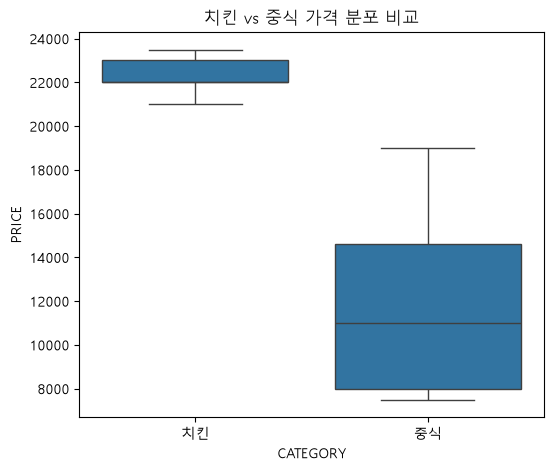

In [14]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.boxplot(data=df[df["CATEGORY"].isin(["치킨", "중식"])], x="CATEGORY", y="PRICE")
plt.title("치킨 vs 중식 가격 분포 비교")
plt.show()